# Pupil Preprocessing

```{admonition} Overview
Pupil preprocessing in PupEyes comes down to:

1. **Initialize `PupilProcessor`** with required information.
2. **Do preprocessing** using a pipeline of methods.
3. **Quality check** using interactive tools.
4. **Finalize**: Exclude trials, finalize data, and save results.
```

Let's keep using the memory task as an example: on each trial, we ask participants to memorize some letters (e.g., XFABWS), and after a while, we present a probe letter (e.g., A) and ask if this letter belongs to the presented letters.  

As a recap, the trial flow looks like this:

```{image} assets/trial.png
:alt: asc_file
:width: 800px
:align: center
```

Our example data consists of four participants completing 10 trials of the task.

## Read Data

In [1]:
import pandas as pd
import pupeyes as pe

Here we will use the formatted data from the [Read Data](read_data_eyelink.ipynb) tutorial. The data contains gaze sample of four subjects each completing 10 trials.

In [2]:
# load data
samples = pd.read_csv('data/samples.csv')

# select only useful columns
samples = samples[['participant','block','trial','event','trialtime','x','y','pp']]

samples

,participant,block,trial,event,trialtime,x,y,pp
0,sub004,A,1,fixation,0,0.0,0.0,0
1,sub004,A,1,fixation,1,0.0,0.0,0
2,sub004,A,1,fixation,2,0.0,0.0,0
3,sub004,A,1,fixation,3,0.0,0.0,0
4,sub004,A,1,fixation,4,0.0,0.0,0
...,...,...,...,...,...,...,...,...
679960,sub001,A,10,feedback,22927,839.7,484.5,5060
679961,sub001,A,10,feedback,22928,839.7,484.4,5062
679962,sub001,A,10,feedback,22929,839.6,485.5,5064
679963,sub001,A,10,feedback,22930,839.5,486.8,5065


```{note}
Although we used Eyelink data here, note that data from any eye-tracker can work as long as it is formatted as the above. Specifically, it needs to have column(s) that identifies an unique trial, a timestamp column, x & y coordinates, and pupil size. You can get the information from most eye-trackers. The "event" column indicates different parts within a single trial and is not strictly needed. 

Check the API reference for more information.
```

## Inititalize PupilProcessor

The first step of pupil processing is to initiate the `PupilProcessor`. We simply feed the following information:

In [3]:
p = pe.PupilProcessor(
    data=samples, # pass your data
    trial_identifier=['participant', 'block', 'trial'], # column(s) that disambiguate one trial from another in your data
    x_col = 'x',
    y_col = 'y',
    pupil_col = 'pp',
    time_col = 'trialtime',
    samp_freq = 1000, # Hz
    convert_pupil_size=False, # see note
    progress_bar=False
    )

Device: eyelink
Eye-tracker missing value for pupil size is 0. No replacement needed.
Sampling frequency check passed. Sampling rate: 1000Hz
PupilProcessor initialized with 679965 samples
Pupil column: pp, Time column: trialtime, X column: x, Y column: y
Trial identifier: ['participant', 'block', 'trial'], Number of trials: 40


In [4]:
p.data

,participant,block,trial,event,trialtime,x,y,pp
0,sub004,A,1,fixation,0,0.0,0.0,0
1,sub004,A,1,fixation,1,0.0,0.0,0
2,sub004,A,1,fixation,2,0.0,0.0,0
3,sub004,A,1,fixation,3,0.0,0.0,0
4,sub004,A,1,fixation,4,0.0,0.0,0
...,...,...,...,...,...,...,...,...
679960,sub001,A,10,feedback,22927,839.7,484.5,5060
679961,sub001,A,10,feedback,22928,839.7,484.4,5062
679962,sub001,A,10,feedback,22929,839.6,485.5,5064
679963,sub001,A,10,feedback,22930,839.5,486.8,5065


```{note}
Eyelink records pupil size in an arbitrary unit (AREA or DIAMETER, depending on your system setting). These arbitrary pupil sizes can be converted to millimeters by [calibrating them against an artificial eye](https://www.sr-research.com/support/thread-154.html). PupEyes can automatically do this for you if you provide the required information. For example: `convert_pupil_size=True`, `artificial_d=5`, `artificial_size=5663`, `recording_unit='diameter'`. This should work with other eye-trackers if you know it is recording an area or a diameter. Refer to the API for more information.
```

## Deblink

Deblinking is finding samples during blinks and setting them as missing. This is usually the first step of pupil preprocessing because blinks cause artificial changes in pupil size. 

Running deblinking is just one line of code:

In [5]:
p = p.deblink()

Running deblink using sampling frequency 1000Hz
✓ Deblinking completed!
  → New column: 'pp_db' (blinks removed)
  → Previous column 'pp' preserved.
  → 0 trial(s) failed.


```{note}
Eyelink automatically detects blinks but its algorithm tends to be over-conservative in marking samples as blinks. For example, it does not account for the opening and closing of eyelids, during which pupil size changes rapidly and can also cause large distortions in the data. Therefore, `PupEyes` uses a novel algorithm introduced by [Hershman et al. (2018)](https://doi.org/10.3758/s13428-017-1008-1) for deblinking, which, based on my own experience, does a better job than Eyelink's default. So, these detected blinks may be different from those you get from `EyelinkReader.get_blinks()` as `.get_blinks() just extracts those automatically detected by Eyelink.
```

For every preprocessing step, PupEyes add a new column with a suffix to store the new data, while preserving the existing data. Here, `pp_db` is the deblinked data.

In [6]:
 # show the first 5 rows
p.data.head(5)

,participant,block,trial,event,trialtime,x,y,pp,pp_db
0,sub004,A,1,fixation,0,0.0,0.0,0,<NA>
1,sub004,A,1,fixation,1,0.0,0.0,0,<NA>
2,sub004,A,1,fixation,2,0.0,0.0,0,<NA>
3,sub004,A,1,fixation,3,0.0,0.0,0,<NA>
4,sub004,A,1,fixation,4,0.0,0.0,0,<NA>


PupEyes also has a `.summary()` method that summarizes each preprocessing step. Here, we only have a summary for deblinking. But as we perform more preprocessing, more columns will be added to the summary data. We will revisit `.summary()` later.

In [7]:
# show the first 5 trials
p.summary().head(5)

,participant,block,trial,n_samples,run_deblink,pct_deblink
0,sub004,A,1,23115,True,0.042743
1,sub004,A,2,23166,True,0.248468
2,sub004,A,3,12197,True,0.169796
3,sub004,A,4,10916,True,0.19705
4,sub004,A,5,22768,True,0.157809


## Downsampling (Optional)

Many modern eye-trackers record pupil data at a very high sampling rate such as 1000 Hz. This may be an overkill given how slow pupillary responses usually are. To speed up processing, it may be desirable to downsample your data to a lower frequency. It is important to note that certain preprocessing steps, such as deblinking, would benefit from high-frequency data. So you may want to downsample after blinks are removed. 

Here we create a copy of the original `PupilProcessor` to demonstrate downsampling. The latter steps are performed without downsampling.

In [8]:
p_downsampled = p.copy() # create a copy of the original instance
p_downsampled.downsample(target_samp_freq=100) # downsample to 100 Hz

Sampling frequency check passed. Sampling rate: 100Hz
✓ Downsampling completed!
  → New sampling frequency: 100 Hz
  → 0 trial(s) failed.


As the `trialtime` column indicates the data are now at 100 Hz:

In [9]:
p_downsampled.data.head(5)

,participant,block,trial,event,trialtime,x,y,pp,pp_db
0,sub004,A,1,fixation,0,0.0,0.0,0,<NA>
1,sub004,A,1,fixation,10,0.0,0.0,0,<NA>
2,sub004,A,1,fixation,20,0.0,0.0,0,<NA>
3,sub004,A,1,fixation,30,0.0,0.0,0,<NA>
4,sub004,A,1,fixation,40,0.0,0.0,0,<NA>


PupEyes also has an `upsample` method in case you want to align your data with those recorded from other devices that have a higher sampling rate. More info: [API Reference](api.rst).

## Artifact Rejection

Besides blinking, many other factors can introduce pupil size artifacts (e.g., head movement). Therefore, it is a good idea to do further cleaning after deblinking.

PupEyes implements an `artifact_rejection()` method for this purpose. The user can choose to remove artifacts based on one or both of these methods:

1. **Rapid change in pupil size.** This method identifies rapid *changes* in pupil size. The speed threshold is set as a constant `speed_n` * the Median Absolute Deviation (MAD) of pupil speeds. The default value of `speed_n` = 16. This method is recommended [here](https://link.springer.com/article/10.3758/s13428-018-1075-y), [here](https://doi.org/10.3758/s13428-020-01374-8), and [here](https://dr-jt.github.io/pupillometry/articles/remove_unlikely.html). 
   
3. **Extreme pupil sizes.** This method identifies extreme pupil sizes based on z-scores while protecting stable data from being removed, based on an implementation [here](https://github.com/esdalmaijer/PyGazeAnalyser/blob/de44913fb60876134c5b942690d586e5dab40476/pygazeanalyser/traces.py#L371).

The default is to use both methods but the user may choose to use only one with `method='speed'` or `method='zscore'`.

In [10]:
p = p.artifact_rejection()

✓ Artifact rejection completed!
  → New column: 'pp_db_ar' (artifacts removed)
  → Previous column 'pp_db' preserved.
  → 0 trial(s) failed.


## Filter Gaze Positions

Many pupillometry experiments restrict eye movements for a good reason: to minimize the **pupil foreshortening error**, that is, size artifacts introduced when the eyeballs rotate away from the camera. Therefore, it may be a good idea to remove samples that deviate too much from the screen center. PupEyes provides a `filter_position` method for this purpose.

You just need to provide a list of vertices that define your "good" region. For this example, we will set the region to be the screen. Any samples looking outside of the screen will be removed.

In [11]:
# vertices are in Eyelink coordinates (top-left corner (0,0)); last point to close the polygon
vertices = [(0,0), (0, 1080), (1920, 1080), (1920, 0), (0,0)] 
p = p.filter_position(vertices=vertices)

✓ Gaze spatial filtering completed!
  → New column: 'pp_db_ar_xy' (gaze filtered)
  → Previous column 'pp_db_ar' preserved.
  → 0 trial(s) failed.


## Smooth Data

Even with a perfect participant, eye-trackers themselves produce high-frequency noise that should be smoothed out before analysis. There are many ways to smooth the data. PupEyes provides three options:
1. Hanning window (`method='hann'`)
2. Rolling mean (`method='rollingmean'`)
3. Butterworth low-pass filter (`method='butter'`; requires non-missing data, so interpolate data first)

Here, we will use the Hanning window with a window size of 100 (i.e., 100 samples), which is the default option.

In [12]:
p = p.smooth()

✓ Smoothing completed!
  → New column: 'pp_db_ar_xy_sm' (smoothed)
  → Previous column 'pp_db_ar_xy' preserved.
  → 0 trial(s) failed.


## Check Missing Data

So far we have set pupil size values to missing for various reasons. It is a good idea to check for missingness at this point to get a sense data quality.

In [13]:
p = p.check_missing() # default is the lastest pupil size column

✓ Missing values checked!
  → 0 trial(s) failed.


In [14]:
p.summary().head(5)

,participant,block,trial,n_samples,run_deblink,pct_deblink,run_speed,pct_speed,run_size,pct_size,run_gaze_filter,pct_gaze_filter,avg_gaze_x,avg_gaze_y,run_smooth,run_check_missing,missing
0,sub004,A,1,23115,True,0.042743,True,0.000692,True,0,True,0.001298,932.023893,592.014834,True,True,0.061302
1,sub004,A,2,23166,True,0.248468,True,0.001597,True,0,True,0.03203,975.807543,604.144581,True,True,0.340456
2,sub004,A,3,12197,True,0.169796,True,0.002378,True,0,True,0.018775,955.872528,597.951776,True,True,0.250143
3,sub004,A,4,10916,True,0.19705,True,0.002657,True,0,True,0.066141,954.471826,580.816997,True,True,0.323837
4,sub004,A,5,22768,True,0.157809,True,0.001976,True,0,True,0.022356,942.64441,585.789132,True,True,0.251669


Since `.summary()` returns a pandas dataframe, you can use the "usual" pandas stuff for additonal analyses. For example, drawing a histogram of missing proportions:

<Axes: >

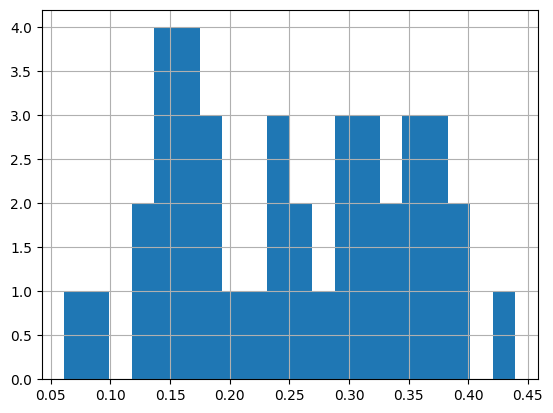

In [15]:
p.summary().missing.hist(bins=20)

## Interpolate Missing Values

It may be desirable to interpolate these missing values to get more "complete" traces. But if there is too much missing data to be interpolated, the results might not be trustworthy. PupEyes supports linear or spline interpolation while setting the maximum proportion of missing values allowed for interpolation.

In [16]:
# linear interpolation (default) for trials with missing pct < 40%
p = p.interpolate(missing_threshold=0.4)

✓ Interpolation completed!
  → New column: 'pp_db_ar_xy_sm_it' (interpolated)
  → Previous column 'pp_db_ar_xy_sm' preserved.
  → 1 trial(s) failed.

   participant block  trial
0      sub001     A      6


## Baseline Correction

If you are interested in task-evoked pupillary responses, it is desirable to do baseline correction to get "cleaner" evoked responses. There are two ways to do baseline correction: 

1. Subtractive: corrected size = pupil size - baseline
2. Divisive: correct size = pupil size / baseline

There is a [compelling argument](https://doi.org/10.3758/s13428-017-1007-2) to **avoid divisive baseline correction** due to its proneness to producing outliers. PupEyes by default uses the subtractive method.

PupEyes assumes that the baseline data is in the same dataframe as the to-be-corrected data. In our example, the baseline period consists of gaze samples occurred during the `fixation` period.

We will set the baseline data to the `"fixation"` period and use the mean of the last 100 samples for the actual correction on each trial.

In [17]:
p = p.baseline_correction(baseline_query='event=="fixation"', baseline_range=[-100, None])

✓ Baseline correction completed!
  → New column: 'pp_db_ar_xy_sm_it_bc' (baseline corrected)
  → Previous column 'pp_db_ar_xy_sm_it' preserved.
  → 1 trial(s) failed.

   participant block  trial
0      sub001     A      6


```{note}
- The query string for `baseline_query` is used in the `.query()` method in pandas, see: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.query.html>
- The list-slicing syntax for the `baseline_range` argument makes it easy to specify different ranges of baseline data. E.g., `[None, None]` to use all baseline data, `[-100, None]` to use the last 100 samples, `[None, 100]` to use the first 100 samples, etc.
```

Now we have performed a series of preprocessing steps. PupEyes adds a new column with a suffix for each preprocessing step to preserve existing data:
- `_db`: Deblink
- `_ar`: Artifact rejection
- `_xy`: Filter gaze position
- `_sm`: Smoothing
- `_it`: Interpolation
- `_bc`: Baseline correction

In [18]:
p.data.head(5)

,participant,block,trial,event,trialtime,x,y,pp,pp_db,pp_db_ar,pp_db_ar_xy,pp_db_ar_xy_sm,pp_db_ar_xy_sm_it,pp_db_ar_xy_sm_it_bc
0,sub004,A,1,fixation,0,0.0,0.0,0,<NA>,<NA>,<NA>,<NA>,5670.567834,550.902786
1,sub004,A,1,fixation,1,0.0,0.0,0,<NA>,<NA>,<NA>,<NA>,5670.567834,550.902786
2,sub004,A,1,fixation,2,0.0,0.0,0,<NA>,<NA>,<NA>,<NA>,5670.567834,550.902786
3,sub004,A,1,fixation,3,0.0,0.0,0,<NA>,<NA>,<NA>,<NA>,5670.567834,550.902786
4,sub004,A,1,fixation,4,0.0,0.0,0,<NA>,<NA>,<NA>,<NA>,5670.567834,550.902786


## Chained Operations

The above operations can be chained together as a complete processing pipeline. 

In [19]:
p = pe.PupilProcessor(
    data=samples,
    trial_identifier=['participant', 'block', 'trial'],
    x_col = 'x',
    y_col = 'y',
    pupil_col = 'pp',
    time_col = 'trialtime',
    samp_freq = 1000,
    convert_pupil_size=False,
    progress_bar=True
    )\
    .deblink()\
    .artifact_rejection()\
    .filter_position(vertices=vertices)\
    .smooth()\
    .check_missing()\
    .interpolate(missing_threshold=.4)\
    .baseline_correction(baseline_query='event=="fixation"', baseline_range=[-100, None])

Device: eyelink
Eye-tracker missing value for pupil size is 0. No replacement needed.
Sampling frequency check passed. Sampling rate: 1000Hz
PupilProcessor initialized with 679965 samples
Pupil column: pp, Time column: trialtime, X column: x, Y column: y
Trial identifier: ['participant', 'block', 'trial'], Number of trials: 40
Running deblink using sampling frequency 1000Hz


Deblinking:   0%|          | 0/40 [00:00<?, ?it/s]

✓ Deblinking completed!
  → New column: 'pp_db' (blinks removed)
  → Previous column 'pp' preserved.
  → 0 trial(s) failed.


Artifact rejection:   0%|          | 0/40 [00:00<?, ?it/s]

✓ Artifact rejection completed!
  → New column: 'pp_db_ar' (artifacts removed)
  → Previous column 'pp_db' preserved.
  → 0 trial(s) failed.


...

✓ Missing values checked!
  → 0 trial(s) failed.


Interpolating:   0%|          | 0/40 [00:00<?, ?it/s]

✓ Interpolation completed!
  → New column: 'pp_db_ar_xy_sm_it' (interpolated)
  → Previous column 'pp_db_ar_xy_sm' preserved.
  → 1 trial(s) failed.

   participant block  trial
0      sub001     A      6


Baseline correction:   0%|          | 0/40 [00:00<?, ?it/s]

✓ Baseline correction completed!
  → New column: 'pp_db_ar_xy_sm_it_bc' (baseline corrected)
  → Previous column 'pp_db_ar_xy_sm_it' preserved.
  → 1 trial(s) failed.

   participant block  trial
0      sub001     A      6


## PupilViewer: Interactive App for Inspecting Pupil Traces

It is critical to use the `PupilViewer` to examine the quality of preprocessing. PupilViewer is built on `Plotly Dash`, an interactive web-based library for data visualization.

With `PupilViewer`, you can check if operations like deblinking, interpolation, and baseline correction are done properly.

To launch PupilViewer, create an instance by passing your `PupilProcessor` object to PupilViewer and call `run()`. Use the dropdown menus to select which trial and columns to plot.

You can hover over data points, drag, use the toolbar to zoom in/out, and more. Below is a screenshot of running it on my machine.

In [20]:
viewer = pe.PupilViewer(p, hue='event')

#viewer.run()

```{image} assets/pupil_viewer.gif
:name: pupil_viewer
```

```{tip}
You can adjust how the app is run, such as whether it runs inline or in another tab, window size, etc., by passing keyword arguments to `run_server().` See <https://dash.plotly.com/dash-in-jupyter>
```

## Diagnostic Plots

In addition to `PupilViewer`, PupEyes provides three interactive diagnostic plots to examine outlier data.

### Gaze Position

As much as we want participants' eyes to stay still, we can never completely avoid the pupil foreshortening error. Sometimes, participants drift away from the screen center, either intentionally or unintentionally. Other times, though, the experimenter may display stimuli that encourage eye movements (such as a picture). In these cases, we have to make sure that gaze positions do not confound with the experimental variable we are interested in.

The `plot_pupil_surface()` function visualizes the extent of gaze spread, which may help you determine the extent of pupil foreshortening error. In the example below, we plot a 2D histogram of pupil size measurements as a function of their gaze coordinates. The red cross shows the average gaze position.

Note that here we do not have a condition variable, so we will just use `participant` instead. This will visualize if different participants fixated at different positions.

In [21]:
p.plot_pupil_surface(
    pupil_col='pp_db_ar_xy', # the remaining pupil measurements right after the gaze filtering step
    plot_by='participant', # here we plot by participant but you can also plot by an experimental condition if you like
    vertices=vertices, # you can optionally pass a region you used for filtering
    show_centroid=True # use False if it blocks data
)

As can be seen from this plot, our participants seemed to follow our instructions pretty well: they were fixating on the screen center most of the time.

`plot_pupil_surface()` is meant to provide a visualization only and doesn't give you a statistical test of positional biases. However, if you include `filter_position()` in your preprocessing pipeline, you can see `avg_gaze_x` and `avg_gaze_y` columns in the summary data. These are the average gaze position for the remaining samples (i.e., after spatial filtering) for each trial. This information might be useful for additional analyses on gaze positions.

In [22]:
gaze_info = p.summary()[['participant','block','trial','run_gaze_filter','pct_gaze_filter','avg_gaze_x','avg_gaze_y']]
gaze_info.head(5)

,participant,block,trial,run_gaze_filter,pct_gaze_filter,avg_gaze_x,avg_gaze_y
0,sub004,A,1,True,0.001298,932.023893,592.014834
1,sub004,A,2,True,0.03203,975.807543,604.144581
2,sub004,A,3,True,0.018775,955.872528,597.951776
3,sub004,A,4,True,0.066141,954.471826,580.816997
4,sub004,A,5,True,0.022356,942.64441,585.789132


For example, we can compute the average gaze position for each participant and block:

In [23]:
# compute the mean gaze after filtering for each participant
gaze_info.groupby(['participant','block'])[['avg_gaze_x','avg_gaze_y']].mean()

,,avg_gaze_x,avg_gaze_y
participant,block,,
sub001,A,858.581525,505.699754
sub002,A,976.501251,528.794445
sub003,A,972.302633,543.972819
sub004,A,946.053655,590.897507


If there are systematic biases in gaze position exist in your data, you might want to remove certain subjects/blocks/trials, or use a smaller region for `filter_position()`.

### Extreme Baseline Values

Recall that we specified the last 100 samples of the fixation period as our baseline data. Well, what if some of these baseline pupil size values were distorted somehow?
PupEyes provides a `check_baseline_outliers` method to detect baseline outliers. The outlier threshold is set as a constant `n_mad_baseline`* MAD. 

You can optionally do the outlier detection by group.

In [24]:
p = p.check_baseline_outliers(
    n_mad_baseline=4, # larger values mean wider thresholds
    outlier_by='participant', # do outlier detection by participant
)

Checking baseline pupil sizes for outliers:   0%|          | 0/4 [00:00<?, ?it/s]

✓ Baseline outlier detection completed!
  → 3 trial(s) detected as baseline outliers.

    participant block  trial
20      sub002     A      1
32      sub001     A      3
37      sub001     A      8


### Outlier Traces

Another useful visualization is to plot the pupil size traces in one spaghetti plot. [Mathôt and Vilotijević (2022)](https://link.springer.com/article/10.3758/s13428-022-01957-7) says that 

> Good-quality data will look like a tangle of lines.
> 
> A key sign of poor data quality is the presence of spikes that shoot downwards (but rarely upwards) from this tangle of lines: these spikes correspond to blinks or other recording artifacts that were not successfully interpolated or removed.
>
> Another sign of poor data quality is the presence of lines that are far above (but rarely below) the others, or that start from zero but then quickly (< 200 ms) shoot upwards: these lines correspond to trials on which there were artifacts during the baseline period, resulting in extremely small baseline pupil sizes (which should also be evident in the histogram of baseline pupil sizes) and thus extremely large baseline-corrected pupil sizes.

PupEyes identifies outlier traces by comparing the max and min values of individual traces against an outlier threshold. This threshold is defined as a constant `n_mad_trace` * the MAD of max trace deviations from the overall mean. The default `n_mad_trace` is set to 4. If, at any point, a pupil trace crosses that threshold, it is marked as an outlier trace. 

Select sub004 from the dropdown menu to inspect the detected outlier trace.

In [25]:
p = p.check_trace_outliers(
    pupil_col = 'pp_db_ar_xy_sm_it_bc', # which pupil column?
    n_mad_trace=3, # larger values mean wider thresholds; setting to 3 here to get an outlier trace as example
    outlier_by= 'participant' # do outlier detection by participant
)

Checking trace outliers for pp_db_ar_xy_sm_it_bc


Checking pupil traces for outliers:   0%|          | 0/40 [00:00<?, ?it/s]

✓ Trace outlier detection completed!
  → 1 trial(s) detected as trace outliers.

   participant block  trial
1      sub004     A      2


```{attention}

Do not blindly follow outlier detection results, especially when using default values. These default values are arbitrary and may not be appropriate for your specific study. In the end, the researcher must carefully decide what constitutes an outlier for their own study.
```

## Summary Data

The `.summary()` method returns a `pandas` dataframe that shows a summary of the preprocessing steps:

In [26]:
p.summary().head(5) # showing the first 5 rows

,participant,block,trial,n_samples,run_deblink,pct_deblink,run_speed,pct_speed,run_size,pct_size,...,run_interpolate,pct_interpolate,run_baseline_correction,baseline,baseline_outlier,baseline_upper,baseline_lower,trace_outlier,trace_upper,trace_lower
0,sub004,A,1,23115,True,0.042743,True,0.000692,True,0,...,True,0.061302,True,5119.665049,False,6171.273173,4460.529201,False,1300.677704,-1219.819811
1,sub004,A,2,23166,True,0.248468,True,0.001597,True,0,...,True,0.340456,True,4979.91167,False,6171.273173,4460.529201,True,1300.677704,-1219.819811
2,sub004,A,3,12197,True,0.169796,True,0.002378,True,0,...,True,0.250143,True,5547.351041,False,6171.273173,4460.529201,False,1300.677704,-1219.819811
3,sub004,A,4,10916,True,0.19705,True,0.002657,True,0,...,True,0.323837,True,6072.677204,False,6171.273173,4460.529201,False,1300.677704,-1219.819811
4,sub004,A,5,22768,True,0.157809,True,0.001976,True,0,...,True,0.251669,True,5971.157678,False,6171.273173,4460.529201,False,1300.677704,-1219.819811


`.summary()` helps you develop a principled way of defining "bad" trials. For example, we mark any trial that has a failed processing step or is an outlier as a bad trial:

In [27]:
# get bad trials based on the summary data
p.bad_trials = p.summary().query('run_deblink==False | run_speed==False | run_size==False | run_gaze_filter==False | run_smooth==False | run_interpolate==False | run_baseline_correction==False | baseline_outlier==True | trace_outlier==True', engine='python')[['participant','block','trial']]
p.bad_trials

,participant,block,trial
1,sub004,A,2
20,sub002,A,1
32,sub001,A,3
35,sub001,A,6
37,sub001,A,8


You will notice that these "bad" trials consist of the one trial we did not interpolate (or baseline correct) due to high missingness, 3 trials with extreme baseline values, and 1 trial with outlier trace.

```{tip}
Above is just an example of defining bad trials. You can of course define alternative criteria for trial exclusion. 
For example, you can pass numeric criteria as a query string:

`pct_deblink > .3 | pct_speed > .2 | pct_interpolate > .4`


You can also manually specify trials to exclude:

```python
# adding two more trials
more_bad_trials = pd.DataFrame([
    {'subject':'003', 'block':'A', 'trial':4},
    {'subject':'004', 'block':'A', 'trial':7},
    ])
p.all_bad_trials = pd.concat([p.bad_trials, more_bad_trials])

```

### Validate Trials

Once you have a final dataframe of bad trials, you can run the `.validate_trials()` method, which adds a new column to the data to indicate whether a given sample should be excluded. We simply pass the dataframe of bad trials as an argument:

In [28]:
p = p.validate_trials(p.bad_trials)

This add a Boolean column named `valid` to the pupil size data

In [29]:
p.data.head(5)

,participant,block,trial,event,trialtime,x,y,pp,pp_db,pp_db_ar,pp_db_ar_xy,pp_db_ar_xy_sm,pp_db_ar_xy_sm_it,pp_db_ar_xy_sm_it_bc,valid
0,sub004,A,1,fixation,0,0.0,0.0,0,<NA>,<NA>,<NA>,<NA>,5670.567834,550.902786,True
1,sub004,A,1,fixation,1,0.0,0.0,0,<NA>,<NA>,<NA>,<NA>,5670.567834,550.902786,True
2,sub004,A,1,fixation,2,0.0,0.0,0,<NA>,<NA>,<NA>,<NA>,5670.567834,550.902786,True
3,sub004,A,1,fixation,3,0.0,0.0,0,<NA>,<NA>,<NA>,<NA>,5670.567834,550.902786,True
4,sub004,A,1,fixation,4,0.0,0.0,0,<NA>,<NA>,<NA>,<NA>,5670.567834,550.902786,True


...as well as the summary data.

In [30]:
p.summary().head(5)

,participant,block,trial,n_samples,run_deblink,pct_deblink,run_speed,pct_speed,run_size,pct_size,...,pct_interpolate,run_baseline_correction,baseline,baseline_outlier,baseline_upper,baseline_lower,trace_outlier,trace_upper,trace_lower,valid
0,sub004,A,1,23115,True,0.042743,True,0.000692,True,0,...,0.061302,True,5119.665049,False,6171.273173,4460.529201,False,1300.677704,-1219.819811,True
1,sub004,A,2,23166,True,0.248468,True,0.001597,True,0,...,0.340456,True,4979.91167,False,6171.273173,4460.529201,True,1300.677704,-1219.819811,False
2,sub004,A,3,12197,True,0.169796,True,0.002378,True,0,...,0.250143,True,5547.351041,False,6171.273173,4460.529201,False,1300.677704,-1219.819811,True
3,sub004,A,4,10916,True,0.19705,True,0.002657,True,0,...,0.323837,True,6072.677204,False,6171.273173,4460.529201,False,1300.677704,-1219.819811,True
4,sub004,A,5,22768,True,0.157809,True,0.001976,True,0,...,0.251669,True,5971.157678,False,6171.273173,4460.529201,False,1300.677704,-1219.819811,True


This makes excluding trials easy in subsequent data analysis, as now you have a single column indicating whether we should keep the data or not.

### Customized Summary

You can customize `.summary()` by:
- Show a subset of columns.
- Grouping by different levels (e.g., by subject or condition).
- Specifying custom aggregation methods.

For example, summarizing at the level of `subject` may help you decide whether to remove certain participants or not.

In [31]:
# summary at participant level
p.summary(level='participant', agg_methods={'pct_deblink':'median','valid':'mean'})

,pct_deblink,valid
participant,,
sub001,0.127729,0.7
sub002,0.108811,0.9
sub003,0.244544,1.0
sub004,0.140929,0.9


## Final Steps

After preprocessing, you'll typically want to prepare a final dataset for analysis. For example, you might want to:

- Remove trials we marked as invalid
- Rename the fully preprocessed pupil column to a shorter name
- Remove unnecessary columns
- Keep only data during stimulus presentation and remove baseline data (since we have already done baseline correction)
- If we do the above, also reset the timestamp to stimulus onset
- Merge information from another dataframe

None of these operations require PupEyes; You can do them via standard `pandas` operations.

In [32]:
# 1. Create a final dataset with only valid trials during stimulus presentation
p.final_data = p.data.query('valid==True & event=="stimulus"').reset_index(drop=True)

# 2. Rename the fully preprocessed pupil column to something more manageable
p.final_data['pp_final'] = p.final_data['pp_db_ar_xy_sm_it_bc']

# 3. Select only the relevant columns for analysis
p.final_data = p.final_data[[
    'participant',  # participant ID
    'block',        # block number
    'trial',        # trial number
    'event',        # event marker
    'trialtime',    # time relative to trial onset
    'x', 'y',       # gaze coordinates
    'pp_final'      # preprocessed pupil size
]]

# 4. Create a timestamp column indicating time since stimulus onset using pandas' groupby-transform routine
p.final_data['eventtime'] = p.final_data.groupby(['participant','block','trial']).trialtime.transform(lambda x: x - x.iloc[0]) # reset timestamp for each trial

# 5. Merge necessary information from another dataframe
# Here we assume a between-subject design
trial_info = pd.DataFrame(
    {'participant':['sub001','sub002','sub003','sub004'],
    'group':['A','A','B','B']}
)
p.final_data = p.final_data.merge(trial_info)

# Preview the data
p.final_data.head(5)

,participant,block,trial,event,trialtime,x,y,pp_final,eventtime,group
0,sub004,A,1,stimulus,983,867.3,572.7,-51.159402,0,B
1,sub004,A,1,stimulus,984,867.8,570.9,-51.729276,1,B
2,sub004,A,1,stimulus,985,868.2,569.1,-52.289048,2,B
3,sub004,A,1,stimulus,986,868.3,568.8,-52.839291,3,B
4,sub004,A,1,stimulus,987,867.7,569.7,-53.380616,4,B


## Save Results

Once you are done, you can save all your processing results in a single `.pkl` file for future use. 

In [33]:
# p.save('myproject.pkl')

To load your saved object, simply do the following:

In [34]:
# p = pe.PupilProcessor.load('myproject.pkl')

If you just want to save/load the final data, you can do that via `pandas` since it's just a dataframe:

In [35]:
# # save only the final data 
# p.final_data.to_csv('final_data.csv', index=False)

# # reload the data
# reloaded_data = pd.read_csv('final_data.csv')

## Combining Multiple PupilProcessors

Sometimes, it gets tricky to preprocess data for all participants in one `PupilProcessor` instance, either because of memory consumption or difficulty in inspecting the data. Another scenario is after you have preprocessed some data, a new batch of data comes in, and you don't want to do the repetitive work. In these cases, you may end up having several `PupilProcessor` instances. 

PupEyes allows you to combine these instances into a single instance as long as your preprocessing pipeline is identical across instances.

In [36]:
# Creating an exact copy
p2 = p.copy()
# combine two instances
p_combined = pe.PupilProcessor.combine([p, p2])